---

Import libs again

---

In [25]:
import shutil
import logging
from pathlib import Path
from collections import Counter
import pandas as pd
import numpy as np
from scipy.stats import entropy
import cv2 as cv
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime

---

Config paths again

---

In [27]:
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_PATH = REPORT_DIR / f"quality_cleaning_log_{RUN_TIMESTAMP}.log"

logger = logging.getLogger("quality_cleaning")
logger.setLevel(logging.INFO)
logger.handlers.clear()

# Console handler
console_handler = logging.StreamHandler()
console_handler.setFormatter(
    logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
)
logger.addHandler(console_handler)

# File handler
file_handler = logging.FileHandler(LOG_PATH, encoding="utf-8")
file_handler.setFormatter(
    logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
)
logger.addHandler(file_handler)

logger.info("=== Quality Cleaning Notebook Started ===")
logger.info(f"Run timestamp: {RUN_TIMESTAMP}")
logger.info(f"INTERIM_DIR: {INTERIM_DIR}")
logger.info(f"REPORT_DIR: {REPORT_DIR}")
logger.info(f"Log file: {LOG_PATH}")

print(f"Logging to: {LOG_PATH}")

2026-08-07 03:19:54,256 | INFO | === Quality Cleaning Notebook Started ===
2026-08-07 03:19:54,258 | INFO | Run timestamp: 20260807_031954
2026-08-07 03:19:54,259 | INFO | INTERIM_DIR: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\interim
2026-08-07 03:19:54,260 | INFO | REPORT_DIR: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\reports
2026-08-07 03:19:54,261 | INFO | Log file: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\reports\quality_cleaning_log_20260807_031954.log


Logging to: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\reports\quality_cleaning_log_20260807_031954.log


---

Check for files extension and build an image inventory

---

In [3]:
file_extensions = Counter()

for file_path in INTERIM_DIR.rglob("*"):
    if file_path.is_file():
        file_extensions[file_path.suffix.lower()] += 1

print(f"Total files found: {sum(file_extensions.values())}\n")

for extension, count in file_extensions.most_common():
    print(f"{extension if extension else '[no extension]'} : {count}")

Total files found: 108757

.jpg : 53887
.txt : 52924
.png : 1021
.xml : 877
.jpeg : 45
.csv : 3


---

Build an image inventory

---

In [4]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png"
}

image_records = []

for image_path in INTERIM_DIR.rglob("*"):
    if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
        relative_path = image_path.relative_to(INTERIM_DIR)

        image_records.append({
            "source": relative_path.parts[0],
            "dataset": relative_path.parts[1] if len(relative_path.parts) > 1 else "unknown",
            "extension": image_path.suffix.lower(),
            "image_path": str(image_path)
        })

image_inventory = pd.DataFrame(image_records)

print(f"Total images discovered: {len(image_inventory)}")

image_inventory.head()

Total images discovered: 54953


,source,dataset,extension,image_path
0,roboflow,stairs_detection,.jpg,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
1,roboflow,stairs_detection,.jpg,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
2,roboflow,stairs_detection,.jpg,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
3,roboflow,stairs_detection,.jpg,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
4,roboflow,stairs_detection,.jpg,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...


---

Check image resolution

---

In [5]:
image_properties = []

for _, row in tqdm(image_inventory.iterrows(), total=len(image_inventory)):
    image_path = row["image_path"]

    image = cv.imread(image_path)

    if image is None:
        continue

    height, width, channels = image.shape

    image_properties.append({
        "source": row["source"],
        "dataset": row["dataset"],
        "image_path": image_path,
        "width": width,
        "height": height,
        "channels": channels
    })

image_quality_df = pd.DataFrame(image_properties)

print(f"Images analysed: {len(image_quality_df)}")

image_quality_df.head()

100%|████████████████████████████████████████████████████████████████████████████| 54953/54953 [28:10<00:00, 32.51it/s]


Images analysed: 54953


,source,dataset,image_path,width,height,channels
0,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3
1,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3
2,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3
3,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3
4,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3


---

Image resolution summary

---

In [6]:
print("Image Width Statistics")
print(image_quality_df["width"].describe())

print("\nImage Height Statistics")
print(image_quality_df["height"].describe())

print("\nMost Common Resolutions")

resolution_counts = (
    image_quality_df
    .groupby(["width", "height"])
    .size()
    .sort_values(ascending=False)
    .reset_index(name="count")
)

display(resolution_counts.head(20))

Image Width Statistics
count    54953.000000
mean       777.527123
std        623.616912
min         70.000000
25%        640.000000
50%        640.000000
75%        640.000000
max      12000.000000
Name: width, dtype: float64

Image Height Statistics
count    54953.000000
mean       707.303223
std        489.825343
min         62.000000
25%        640.000000
50%        640.000000
75%        640.000000
max       9504.000000
Name: height, dtype: float64

Most Common Resolutions


,width,height,count
0,640,640,32753
1,416,416,4876
2,1920,1080,2259
3,512,512,980
4,300,400,893
5,300,300,892
6,4032,3024,769
7,640,480,732
8,1280,1280,631
9,768,1024,394


---

Check image blurness

---

In [17]:
# === Blur Score Calculation ===

if "blur_score" in image_quality_df.columns:
    print("Blur score column already exists. Skipping blur calculation.")

else:
    blur_scores = []

    for _, row in tqdm(image_quality_df.iterrows(), total=len(image_quality_df)):
        image = cv.imread(row["image_path"])

        if image is None:
            blur_scores.append(None)
            continue

        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

        blur_score = cv.Laplacian(gray, cv.CV_64F).var()

        blur_scores.append(blur_score)

    image_quality_df["blur_score"] = blur_scores

    print("Blur scores calculated successfully.")

image_quality_df[["dataset", "blur_score"]].head()

Blur score column already exists. Skipping blur calculation.


,dataset,blur_score
0,stairs_detection,1149.673590
1,stairs_detection,1170.921205
2,stairs_detection,244.367793
3,stairs_detection,1456.672676
4,stairs_detection,989.646444


---

Summarize blur score + threshold analysis

---

Overall Blur Score Statistics
count    54953.000000
mean      1951.902709
std       3400.456636
min          0.626545
25%        320.674564
50%        823.294190
75%       1895.509112
max      51462.715950
Name: blur_score, dtype: float64

Lowest Blur Scores


,dataset,blur_score,image_path
27160,pedestrian_detection,0.626545,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27162,pedestrian_detection,0.632881,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27159,pedestrian_detection,0.633405,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27163,pedestrian_detection,0.634202,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27260,pedestrian_detection,0.634229,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27261,pedestrian_detection,0.634690,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27161,pedestrian_detection,0.634870,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27099,pedestrian_detection,0.636760,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27262,pedestrian_detection,0.636860,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27140,pedestrian_detection,0.638621,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...



Dataset Blur Statistics


,count,mean,median,min,max
dataset,,,,,
pedestrian_detection,2224,106.618567,104.456768,0.626545,276.766607
indoor_object_detection,1340,412.736909,242.828064,2.373177,5457.960439
outdoor_objects,2400,750.241504,523.709635,15.988669,4847.003224
indoor_detection_vineeth,2890,829.155789,478.082728,25.798370,15580.445709
indoor_objects_roboflow,130,876.563069,608.812803,21.955861,7447.216085
pedestrian_walk,1000,996.951035,989.776563,645.611128,1324.635656
stairs_detection,233,1064.180171,962.798213,172.133184,4367.925822
footpath_detection,1687,1092.009186,1105.210978,90.858423,3728.295479
light_poles,910,1134.658457,671.079132,6.699037,13232.555570



Blur Threshold Analysis


,Threshold,Images,Percentage (%)
0,10,613,1.12
1,25,928,1.69
2,50,1878,3.42
3,100,3967,7.22
4,200,8897,16.19


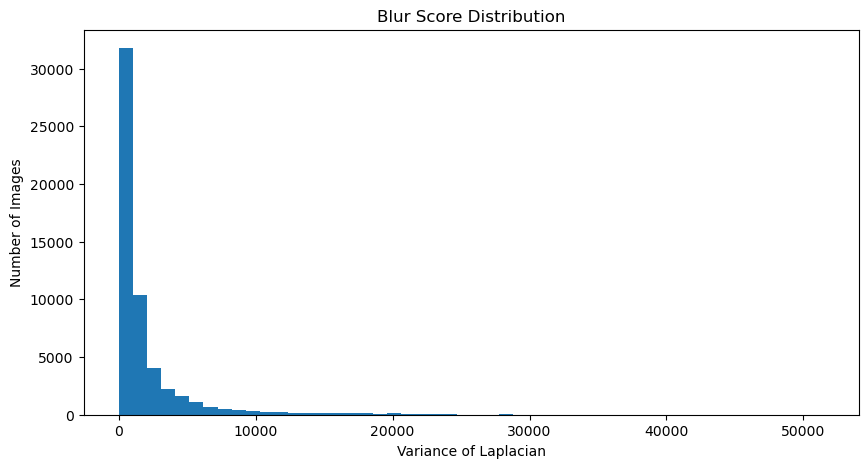

In [16]:
# === Blur Score Analysis ===

if "blur_score" not in image_quality_df.columns:
    print("Blur score column not found. Run blur detection step first.")

else:
    print("=" * 60)
    print("Overall Blur Score Statistics")
    print("=" * 60)
    print(image_quality_df["blur_score"].describe())

    print("\nLowest Blur Scores")
    display(
        image_quality_df[
            ["dataset", "blur_score", "image_path"]
        ]
        .sort_values("blur_score")
        .head(20)
    )

    print("\nDataset Blur Statistics")

    dataset_blur = (
        image_quality_df
        .groupby("dataset")["blur_score"]
        .agg(["count", "mean", "median", "min", "max"])
        .sort_values("mean")
    )

    display(dataset_blur)

    print("\nBlur Threshold Analysis")

    thresholds = [10, 25, 50, 100, 200]

    blur_summary = []

    for threshold in thresholds:
        count = (image_quality_df["blur_score"] < threshold).sum()

        blur_summary.append({
            "Threshold": threshold,
            "Images": count,
            "Percentage (%)": round(count / len(image_quality_df) * 100, 2)
        })

    display(pd.DataFrame(blur_summary))

    plt.figure(figsize=(10, 5))
    plt.hist(image_quality_df["blur_score"], bins=50)

    plt.title("Blur Score Distribution")
    plt.xlabel("Variance of Laplacian")
    plt.ylabel("Number of Images")

    plt.show()

---

Channels/color-mode check

---

In [15]:
# === Channels Check — Color Mode Consistency ===

if "channels" not in image_quality_df.columns:
    print("Channels column not found. Run channel detection step first.")

else:
    print("Channel Count Distribution (Overall)")
    print(image_quality_df["channels"].value_counts())

    print("\nChannel Count by Dataset")
    channel_by_dataset = (
        image_quality_df
        .groupby(["dataset", "channels"])
        .size()
        .unstack(fill_value=0)
    )
    display(channel_by_dataset)

    # Flag datasets that aren't uniformly 3-channel (the expected/normal case)
    mixed_datasets = channel_by_dataset[
        [c for c in [1, 4] if c in channel_by_dataset.columns]
    ]

    if mixed_datasets.empty or (mixed_datasets.sum(axis=1) == 0).all():
        print("All images are 3-channel (RGB) — no color mode inconsistency found")
    else:
        flagged = mixed_datasets[mixed_datasets.sum(axis=1) > 0]
        print("⚠️ Datasets with non-3-channel images found:")
        display(flagged)

Channel Count Distribution (Overall)
channels
3    54953
Name: count, dtype: int64

Channel Count by Dataset


channels,3
dataset,
footpath_detection,1687
indoor_detection_vineeth,2890
indoor_object_detection,1340
indoor_objects_5iwhq,1489
indoor_objects_roboflow,130
light_poles,910
obstacle_detection_kaggle,24249
obstacle_detection_roboflow,9182
outdoor_objects,2400


All images are 3-channel (RGB) — no color mode inconsistency found


---

Blank image check

---

In [18]:
# === Blank Image Detection — Histogram Entropy, Brightness-Invariant ===

if "entropy" in image_quality_df.columns:
    print("Entropy column already exists. Skipping entropy calculation.")

else:
    entropy_scores = []

    for _, row in tqdm(image_quality_df.iterrows(), total=len(image_quality_df)):
        image = cv.imread(row["image_path"])
        if image is None:
            entropy_scores.append(None)
            continue

        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        hist = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
        hist_norm = hist / hist.sum()
        hist_norm = hist_norm[hist_norm > 0]

        entropy_scores.append(entropy(hist_norm, base=2))

    image_quality_df["entropy"] = entropy_scores

    print("Entropy scores calculated successfully.")

image_quality_df.head()

Entropy column already exists. Skipping entropy calculation.


,source,dataset,image_path,width,height,channels,blur_score,entropy
0,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3,1149.673590,7.557065
1,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3,1170.921205,7.717221
2,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3,244.367793,7.302981
3,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3,1456.672676,7.662653
4,roboflow,stairs_detection,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...,416,416,3,989.646444,7.657473


---

Light exposure check

---

In [21]:
# === Exposure Detection — Histogram Clipping ===

required_exposure_cols = {
    "dark_clip_pct",
    "bright_clip_pct",
    "mean_brightness"
}

if required_exposure_cols.issubset(image_quality_df.columns):
    print("Exposure metrics already exist. Skipping exposure calculation.")

else:
    exposure_records = []

    for _, row in tqdm(image_quality_df.iterrows(), total=len(image_quality_df)):
        image = cv.imread(row["image_path"])

        if image is None:
            exposure_records.append({
                "dark_clip_pct": None,
                "bright_clip_pct": None,
                "mean_brightness": None,
            })
            continue

        gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

        hist = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten()
        total_pixels = gray.size

        # % of pixels near pure black (0-10) or pure white (245-255)
        dark_clip_pct = hist[0:10].sum() / total_pixels * 100
        bright_clip_pct = hist[245:256].sum() / total_pixels * 100

        exposure_records.append({
            "dark_clip_pct": dark_clip_pct,
            "bright_clip_pct": bright_clip_pct,
            "mean_brightness": gray.mean(),
        })

    exposure_df = pd.DataFrame(exposure_records)

    image_quality_df["dark_clip_pct"] = exposure_df["dark_clip_pct"]
    image_quality_df["bright_clip_pct"] = exposure_df["bright_clip_pct"]
    image_quality_df["mean_brightness"] = exposure_df["mean_brightness"]

    print("Exposure metrics calculated.")

image_quality_df[["dataset", "dark_clip_pct", "bright_clip_pct", "mean_brightness"]].describe()

100%|████████████████████████████████████████████████████████████████████████████| 54953/54953 [10:15<00:00, 89.27it/s]

Exposure metrics calculated.


,dark_clip_pct,bright_clip_pct,mean_brightness
count,54953.000000,54953.000000,54953.000000
mean,4.466390,6.585248,127.076438
std,12.288288,15.781973,37.447723
min,0.000000,0.000000,1.939216
25%,0.052736,0.075684,108.676489
50%,0.616823,0.634766,125.228698
75%,2.760696,3.872071,144.204031
max,98.222168,98.916641,254.039995


In [23]:
print("Highest Bright-Clip % (most likely overexposed)")
display(
    image_quality_df[["dataset", "bright_clip_pct", "mean_brightness", "image_path"]]
    .sort_values("bright_clip_pct", ascending=False)
    .head()
)

print("\nHighest Dark-Clip % (most likely underexposed)")
display(
    image_quality_df[["dataset", "dark_clip_pct", "mean_brightness", "image_path"]]
    .sort_values("dark_clip_pct", ascending=False)
    .head()
)

print("\nExposure Stats by Dataset")
dataset_exposure = (
    image_quality_df
    .groupby("dataset")[["dark_clip_pct", "bright_clip_pct", "mean_brightness"]]
    .mean()
    .sort_values("bright_clip_pct", ascending=False)
)
display(dataset_exposure)

Highest Bright-Clip % (most likely overexposed)


,dataset,bright_clip_pct,mean_brightness,image_path
12218,obstacle_detection_roboflow,98.916641,254.039995,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
53451,light_poles,98.540222,252.432694,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
53105,light_poles,98.425941,253.288467,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
53473,light_poles,98.242661,252.307145,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
52877,light_poles,97.972443,251.975920,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...



Highest Dark-Clip % (most likely underexposed)


,dataset,dark_clip_pct,mean_brightness,image_path
44123,obstacle_detection_kaggle,98.222168,1.939216,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
44128,obstacle_detection_kaggle,98.021729,2.346116,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
12839,obstacle_detection_roboflow,93.067505,8.300478,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
53101,light_poles,91.418388,8.468484,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...
27267,pedestrian_detection,90.386429,4.534635,D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\i...



Exposure Stats by Dataset


,dark_clip_pct,bright_clip_pct,mean_brightness
dataset,,,
pedestrian_detection,22.712765,14.519819,94.847965
pedestrian_walk,0.352676,12.288494,129.599786
obstacle_detection_roboflow,4.777269,10.813382,135.327192
light_poles,2.189363,9.674079,143.030835
obstacle_detection_kaggle,3.560708,6.505729,130.041429
indoor_object_detection,2.949339,4.816175,119.748122
revised_pedestrian_obstacle_detection,5.001276,3.647471,119.119122
indoor_detection_vineeth,6.460570,3.239516,113.719493
indoor_objects_roboflow,3.716343,2.930701,110.740380


---

Generate a report for this section

---

In [28]:
# === Final Report: Tag Quality Flags + Export ===

BLUR_THRESHOLD = 100
ENTROPY_THRESHOLD = 3.0
BRIGHT_CLIP_THRESHOLD = 90
DARK_CLIP_THRESHOLD = 85

def build_flags(row):
    flags = []
    if row["blur_score"] < BLUR_THRESHOLD:
        flags.append("low_blur")
    if row["entropy"] < ENTROPY_THRESHOLD:
        flags.append("low_entropy")
    if row["bright_clip_pct"] > BRIGHT_CLIP_THRESHOLD:
        flags.append("high_bright_clip")
    if row["dark_clip_pct"] > DARK_CLIP_THRESHOLD:
        flags.append("high_dark_clip")
    return ", ".join(flags) if flags else "none"

image_quality_df["quality_flags"] = image_quality_df.apply(build_flags, axis=1)

flagged_summary = (
    image_quality_df
    .assign(is_flagged=image_quality_df["quality_flags"] != "none")
    .groupby("dataset")["is_flagged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "flagged", "count": "total"})
)
flagged_summary["flagged_pct"] = (flagged_summary["flagged"] / flagged_summary["total"] * 100).round(2)

print("Quality Flag Summary by Dataset")
display(flagged_summary)

report_path = REPORT_DIR / f"quality_cleaning_report_{RUN_TIMESTAMP}.csv"
image_quality_df.to_csv(report_path, index=False)
logger.info(f"Quality cleaning report saved: {report_path}")

print(f"\nReport saved: {report_path}")
print("interim/ left unchanged — no auto-removal this pass, all flagged extremes investigated and confirmed legitimate.")

Quality Flag Summary by Dataset


,flagged,total,flagged_pct
dataset,,,
footpath_detection,1,1687,0.06
indoor_detection_vineeth,43,2890,1.49
indoor_object_detection,334,1340,24.93
indoor_objects_5iwhq,26,1489,1.75
indoor_objects_roboflow,10,130,7.69
light_poles,122,910,13.41
obstacle_detection_kaggle,2605,24249,10.74
obstacle_detection_roboflow,884,9182,9.63
outdoor_objects,83,2400,3.46


2026-08-07 03:20:02,241 | INFO | Quality cleaning report saved: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\reports\quality_cleaning_report_20260807_032001.csv



Report saved: D:\SIT374\WalkBuddy-T2-2026\ML_side\datasets\reports\quality_cleaning_report_20260807_032001.csv
interim/ left unchanged — no auto-removal this pass, all flagged extremes investigated and confirmed legitimate.


---

End of quality cleaning

---